# Regression using TA-Regression Library

TA-Regression is Tiger's Regression API that unifies standard libraries like ``Scikit-learn``, ``glmnet`` , ``statsmodels``, ``bambi\PyMC`` and ``tensorflow-probability``. Additionally, it introduces constraint counterparts for these libraries where they may not natively support constraint handling. This enables users to apply constraints to their regression models, ensuring that the optimization process adheres to specified constraints, thus enhancing model robustness and interpretability.

**Need for TA-Regression**
- Most of the business rules are applied in modelling through directionality (+ve or -ve ) and upper-lower bounds of coefficients.
- Although for some cases directionality or bounds are naturally followed, when training large number of models, enforcing the rules is not straight forward. Most cases it is dealt with post correction of coefficients.
- Scikit-Learn & Statsmodels do not allow us to constraint the coefficients. Even if some other libraries do with limited functionality, we have to use different libraries/APIs.

Following are the gaps in the ecosystem TA-Regression fills.
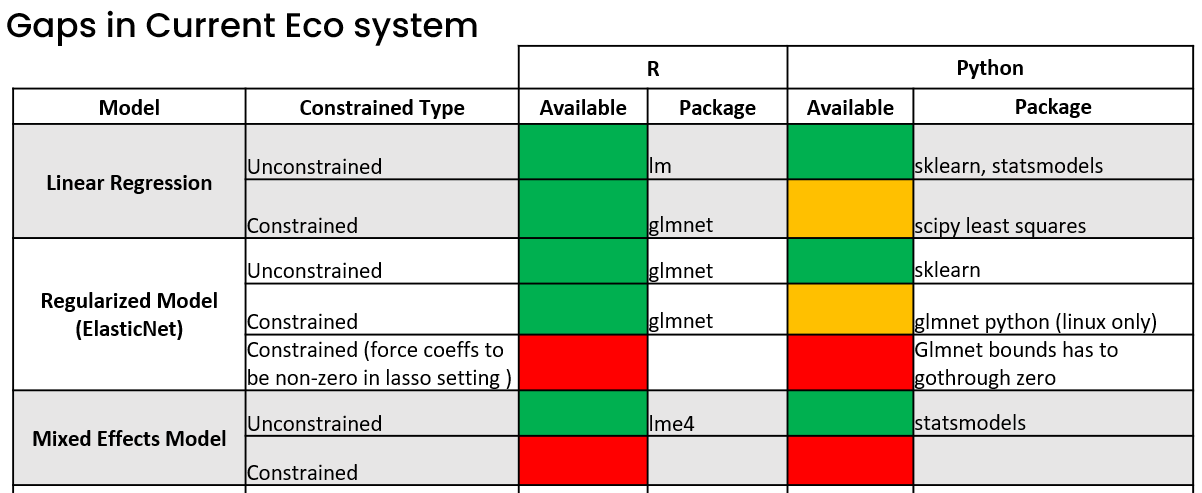

In the previous notebook (i.e ``03_model_experimentating``), we have seen how to do feature engineering including outlier handling and encoding, feature transformation and modelling using sklearn and xgboost libraries.

In this notebook we show the process of model experimenting with [ta_regression](https://tigeranalytics-code-templates.readthedocs-hosted.com/projects/taregression/en/latest/overview.html#taregression) for the same problem statement.

# 1 Setup

**Note**: In order to execute this notebook, you need to install the``tareg`` addons. Follow these steps:

**Step 1**: Activate the code-template environment

**Step 2**:  Execute the command ``inv dev.setup-addon --tareg`` to add the ta_regression addons.

**Step 3 (Optional)**: Run `conda install -c conda-forge -n <env_name> glmnet` to install glmnet package. This step is required only when you intend to use the glmnet backend, and please note that `glmnet` is **only supported on linux**.

In [1]:
%load_ext autoreload
%autoreload 2

### Imports

In [2]:
import warnings
from numba import NumbaDeprecationWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=NumbaDeprecationWarning)

In [3]:
import os
import os.path as op
import shutil

# standard third party imports
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

# impute missing values
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from IPython.display import HTML

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
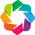

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit
from ta_lib.core.api import (
    custom_train_test_split,
)  # helper function to customize splitting
from scripts import *

In [5]:
# standard code-template imports
from ta_lib.core.api import (
    create_context,
    get_dataframe,
    get_feature_names_from_column_transformer,
    display_as_tabs,
    initialize_environment,
    load_dataset,
    load_pipeline,
    save_dataset,
    DEFAULT_ARTIFACTS_PATH,
    silence_common_warnings,
)
from ta_lib.data_processing.api import Outlier
import ta_lib.eda.api as eda
from ta_lib.regression.api import RegressionComparison, RegressionReport

# ta_regression imports
from taregression.elastic_net_api import ElasticNet
from taregression.linear_mixed_effects_api import LinearMixedEffects
from taregression.bayes_api import BayesianRegression

# from taregression.linear_api import LinearRegression

initialize_environment(debug=False, hide_warnings=True)

2026-08-29 12:54:34.789043: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-29 12:54:34.962400: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-29 12:54:35.456998: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-29 12:54:35.735739: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788008075.914785  191210 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788008075.97

In [7]:
artifacts_folder = DEFAULT_ARTIFACTS_PATH

config_path = op.join("conf", "config.yml")
context = create_context(config_path)

# 2 Feature Engineering

The emphasis here lies on the ``Pipeline`` rather than the model itself. While the model choice guides the pipeline required for training, our objective is to configure it in a manner conducive to saving/loading and easy adaptation for different model selections.

## 2.1 Read the Cleaned Sales Data

In [8]:
sales_data = load_dataset(context, "cleaned/sales")

- We split the data into train and test.
- In this example, we are binning the selling_price into 10 quantiles and then use a Stratified Shuffle to split the data.
- See sklearn documentation on the various available splitters
- https://scikit-learn.org/stable/modules/classes.html#splitter-classes

- After splitting, we filter out rows where the ``quantity`` and ``unit_price`` are negetive as they do not make sense for modelling.

In [9]:
splitter = StratifiedShuffleSplit(
    n_splits=1, test_size=0.2, random_state=context.random_seed
)
# helper function to customize splitting
sales_df_train, sales_df_test = custom_train_test_split(
    sales_data, splitter, by=binned_selling_price
)

sales_df_train = sales_df_train[sales_df_train["quantity"] > 0]
sales_df_train = sales_df_train[sales_df_train["unit_price"] > 0]

sales_df_test = sales_df_test[sales_df_test["quantity"] > 0]
sales_df_test = sales_df_test[sales_df_test["unit_price"] > 0]

len(sales_df_train), len(sales_df_test)

(135828, 34011)

## 2.2 Feature Engineering Pipelines


**Dev NOTES**

For Feature Engineering, sklearn.pipeline.Pipeline are leveraged because of the following advantages
<details>
    
1. It helps in automating workflows and are easier to read and comprehend.
2. Right Sequence can be ensured and (for example always encodes before imputing)
3. Reproducibility is very convenient with pipelines
4. Pipelines help you prevent data leakage in your test data
5. Code is near implementation ready

#### General Steps in the Feature Transformation are as follows
 - Outlier Treatment
 - Encoding of Categorical Columns
 - Missing Values Imputation

In [11]:
# collecting different types of features for transformations (unit_price is the target)
cat_columns = (
    sales_data.loc[:, sales_data.columns != "unit_price"]
    .select_dtypes("object")
    .columns
)
num_columns = (
    sales_data.loc[:, sales_data.columns != "unit_price"]
    .select_dtypes("number")
    .columns
)

#### 2.2.1 Outlier Handling
- A Custom Transformer is used to handle outliers. It is not included as part of the pipeline as outliers handling are optional for test data
- An option to either drop or cap the outliers can be passed during the transform call
- If we want to treat outliers for some columns them we can pass cols argument to the Transformer

In [12]:
outlier_transformer = Outlier(method="mean")
print(sales_df_train.shape)

sales_df_train = outlier_transformer.fit_transform(sales_df_train)
print(sales_df_train.shape)

(135828, 33)
(135828, 33)


#### 2.2.2 Encoding

Some notes on how to create column specific pipelines and integrating them overall is presented below-

- Commonly target encoding is done for categorical variables with too many levels.
- For fewer categorical levels one hot encoding/label encoding is preferred.
- If there is one dominant level, we can use binary encoding.
- As shown in the ``03_model_experimentation`` notebook, we proceed with Target Encoding as the categorical variables are present with too many levels
- **NOTE**: Unlike the ``03_model_experimentation`` notebook, ``brand`` column is not encoded as it will be used in TA Regression's ``LinearMixedEffects`` model as a grouping factor. This will be explained once you reach Section 3.2


In [13]:
tgt_enc_simple_impt = Pipeline(
    [
        ("target_encoding", TargetEncoder(return_df=False)),
        ("simple_impute", SimpleImputer(strategy="most_frequent")),
    ]
)


# NOTE: the list of transformations here are not sequential but weighted
# (if multiple transforms are specified for a particular column)
# for sequential transforms use a pipeline as shown above.
features_transformer = ColumnTransformer(
    [
        ## categorical columns
        (
            "tgt_enc",
            TargetEncoder(return_df=False),
            list(
                set(cat_columns)
                - set(["technology", "functional_status", "platforms", "brand"])
            ),
        ),
        # NOTE: if the same column gets repeated, then they are weighed in the final output
        # If we want a sequence of operations, then we use a pipeline but that doesen't YET support
        # get_feature_names.
        (
            "tgt_enc_sim_impt",
            tgt_enc_simple_impt,
            ["technology", "functional_status", "platforms"],
        ),
        ## numeric columns
        ("med_enc", SimpleImputer(strategy="median"), num_columns),
    ]
)

## 2.3 Feature analysis

Using the pipeline above, we analyze the features and decide on additional features to add/remove from the pipeline.

Here we are primarily focused on feature selection/elimination based on business rules, prior knowledge, data analysis.

**We are not building any models at this point.**


First, we run our Feature Engineering Pipeline on a small fraction of data to test if it works as a best practice. This allows you to validate the pipeline and also identify issues faster.

In [14]:
sample_X = sales_df_train.loc[:, sales_df_train.columns != "unit_price"].sample(
    frac=0.1, random_state=context.random_seed
)
sample_y = sales_df_train[["unit_price"]].loc[sample_X.index]

sample_train_X = get_dataframe(
    features_transformer.fit_transform(sample_X, sample_y),
    get_feature_names_from_column_transformer(features_transformer),
)

# nothing to do for target
sample_train_y = sample_y

Since the feature transformer worked on the sample data, we are proceeding to apply it on the entire dataset

In [15]:
# Keeping the unencoded brand for using as grouping factor in Linear Mixed Effects
brand = sales_df_train[["brand"]]
train_X = sales_df_train.loc[:, sales_df_train.columns != "unit_price"]

In [16]:
train_X = get_dataframe(
    features_transformer.fit_transform(train_X, sales_df_train[["unit_price"]]),
    get_feature_names_from_column_transformer(features_transformer),
)
train_X = pd.concat(
    [train_X.reset_index(drop=True), brand.reset_index(drop=True)], axis=1
)
sales_df_train = pd.concat(
    [
        train_X.reset_index(drop=True),
        sales_df_train[["unit_price"]].reset_index(drop=True),
    ],
    axis=1,
)
sales_df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135828 entries, 0 to 135827
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   condition                 135828 non-null  float64
 1   color                     135828 non-null  float64
 2   inventory_id              135828 non-null  float64
 3   lock_status               135828 non-null  float64
 4   carrier                   135828 non-null  float64
 5   sales_person              135828 non-null  float64
 6   memory_size               135828 non-null  float64
 7   customername              135828 non-null  float64
 8   order_type                135828 non-null  float64
 9   source_channel            135828 non-null  float64
 10  ext_model_family          135828 non-null  float64
 11  model_family              135828 non-null  float64
 12  sku                       135828 non-null  float64
 13  manufacturer              135828 non-null  f

In [17]:
# converting numerical columns to float type
numeric_columns = list(set(train_X.columns) - set(cat_columns))
sales_df_train[numeric_columns] = sales_df_train[numeric_columns].astype(float)

In [18]:
# Transformed data
sales_df_train.head()

,condition,color,inventory_id,lock_status,carrier,sales_person,memory_size,customername,order_type,source_channel,...,line,quantity,unit_cost,selling_price,selling_cost,gp,first_time_customer,days_since_last_purchase,brand,unit_price
0,108.071436,135.849048,139.816804,129.981576,132.176936,144.011378,108.578540,194.289240,130.126765,128.901887,...,21000.0,100.0,160.490,17000.0,16049.03,950.97,0.0,0.0,APPLE,170.0
1,100.414058,148.719500,59.870745,129.981576,132.176936,117.142992,71.595727,104.418583,130.126765,128.901887,...,34000.0,20.0,62.999,1100.0,1259.99,-159.99,0.0,0.0,APPLE,55.0
2,108.071436,135.849048,106.477876,129.981576,132.176936,117.142992,84.054492,110.176245,130.126765,128.901887,...,20000.0,1.0,68.086,110.0,68.09,41.91,0.0,0.0,APPLE,110.0
3,108.071436,58.259438,87.042071,129.981576,132.176936,117.142992,108.578540,102.462919,130.126765,128.901887,...,74000.0,8.0,58.136,704.0,465.09,238.91,0.0,0.0,APPLE,88.0
4,108.071436,135.219462,52.973025,129.981576,132.176936,117.142992,71.595727,96.897926,130.126765,128.901887,...,51000.0,2.0,37.691,102.0,75.38,26.62,0.0,0.0,APPLE,51.0


### 2.3.1 Univariate

- Now that we have our transformed data from our pipelines, we can look at each variable independently. This is useful if your models have assumptions on the distribution and/or bounds on the features/target.

- Since this was already covered in ``03_model_experimentation`` notebook , we will skip it here.

### 2.3.2 Bivariate - mutual interactions

- Here we find columns with high correlations and drop them.
- As observed in ``03_model_experimentation`` notebook, we will be dropping some features due to high correlation.

In [19]:
# channel and source_channel highly correlated. So discarding source_channel
# manufacturer is always Apple so discarding manufacturer.
# Similarly keeping sku between inventory and sku
# Similarly keeping condition between conditions and ext_grade
# Similarly keeping ext_model_family between platforms, ext_model_family and model_family
# Discarding selling price & selling cost as they are multiples of unit price/cost & quantity.
# Discarding gp as it is the difference of selling price and selling cost
# # order_no, line, invoice_no & customername cannot be IDVs
# discarding color since it has no impact on sales
curated_columns = list(
    set(sales_df_train.columns.to_list())
    - set(
        [
            "source_channel",
            "manufacturer",
            "inventory_id",
            "ext_grade",
            "model_family",
            "line",
            "inventory_id",
            "gp",
            "selling_price",
            "selling_cost",
            "invoice_no",
            "customername",
            "order_no",
            "color",
            "tgt_enc_sim_impt_x1",
            "tgt_enc_sim_impt_x2",
            "tgt_enc_sim_impt_x0",
        ]
    )
)

sales_df_train = sales_df_train[curated_columns]

### 2.3.3 Applying the fitted Feature Engineering Pipeline on the test data

- Now that we have finished Feature Engineering + Feature Analysis on the train data, we will transform the test data using the same pipelines

In [20]:
brand = sales_df_test[
    ["brand"]
]  # Keeping the unencoded brand for using as grouping factor in Linear Mixed Effects
test_X = sales_df_test.loc[:, sales_df_test.columns != "unit_price"]
test_X = get_dataframe(
    features_transformer.fit_transform(test_X, sales_df_test[["unit_price"]]),
    get_feature_names_from_column_transformer(features_transformer),
)
test_X = pd.concat(
    [test_X.reset_index(drop=True), brand.reset_index(drop=True)], axis=1
)
sales_df_test = pd.concat(
    [
        test_X.reset_index(drop=True),
        sales_df_test[["unit_price"]].reset_index(drop=True),
    ],
    axis=1,
)
sales_df_test = sales_df_test[curated_columns]

In [21]:
# dropping none values
sales_df_train = sales_df_train.dropna().reset_index(drop=True)
sales_df_test = sales_df_test.dropna().reset_index(drop=True)
print(sales_df_train.shape)
print(sales_df_test.shape)

(135808, 16)
(34003, 16)


We have now completed the preparation of the data and are ready to move to Modelling with TA Regression

# 3 Modelling

## Background Recap

Customer is a distributor of electronic devices. They partner with manufacturers, carriers and refurbishers and sell across to  retailers. The selling price is the outcome of negotiation between sales representatives and retailers. Customer wants to understand the selling price variation and determine  optimal pricing with Machine Learning.

The objective of this notebook is to get the feature coefficients by modelling unit prices as a function of unit cost and other variables. First we will  create models that can predict prices only for one brand at a time (using TA Regression's ``ElasticNet`` model) and compare their performances, and then we'll create models that can predict prices for all brands at the same time (using TA Regression's ``LinearMixedEffects`` and ``BayesianRegression`` Models).

## 3.1 TA Regression's ElasticNet

This Model is wrapper of the Scikit-learn, glmnet-python and ta regression elasticnet algorithms.

### 3.1.1 Simple Additive ElasticNet model

- We can build a model by implementing the Regularised regression using `ElasticNet` API

- Let's model the elastic net using the `scikit-learn` backend, where we have to provide the `lmbd` parameter (shrinkage) explicitly.

- Given the nested nature of data, models needs to be run per group. Here, ``brand`` is identified as a grouping factor since prices, sales tend to vary based on brand (ex. APPLE, SAMSUNG, HTC etc).

- Hence, ElasticNet will be run at the brand level. We take an example of a single brand APPLE.

To know about available backends in ElasticNet, please refer [here](https://tigeranalytics-code-templates.readthedocs-hosted.com/projects/taregression/en/latest/overview.html#elasticnet)

In [22]:
brand = "APPLE"
df_merged_one_brand = sales_df_train[sales_df_train["brand"] == brand]
df_merged_test_one_brand = sales_df_test[sales_df_test["brand"] == brand]
len(df_merged_one_brand), len(df_merged_test_one_brand)

(130245, 32535)

Specifying the model equation is very similar to [`R lang` `lme4`](https://bbolker.github.io/mixedmodels-misc/glmmFAQ.html#model-specification) style Wilkinson's formulas.

In [23]:
model_equation = (
    "unit_price ~  unit_cost + carrier + "
    + "condition + days_since_last_purchase + "
    + "first_time_customer + lock_status + "
    + "memory_size + quantity + ext_model_family + "
    + "sales_person + business_unit + channel +order_type"
)

In [24]:
en_model = ElasticNet(model_equation, backend="sklearn")
en_model.fit(df_merged_one_brand, alpha=0.5, lmbd=0.3, max_iter=10000)
en_model.get_coefficients()

{'Intercept': -0.0,
 'unit_cost': 0.394619683952792,
 'carrier': -0.039795718057575494,
 'condition': 0.3898083589328711,
 'days_since_last_purchase': 0.0,
 'first_time_customer': 0.08667817026180406,
 'lock_status': 0.06818410794859385,
 'memory_size': 0.1832965655906483,
 'quantity': 0.0658692161291121,
 'ext_model_family': 0.5804970845845149,
 'sales_person': 0.08436293560731366,
 'business_unit': 0.06366975431429253,
 'channel': -0.12255175105849449,
 'order_type': -0.8980970905300468}

As you can see in the above example, too many features have been suppressed, indicating that the chosen `lmbd` value might be big. Lets try another experiment with a smaller `lmbd` value 

In [25]:
en_model.fit(df_merged_one_brand, alpha=0.5, lmbd=0.003, max_iter=10000)
en_model.get_coefficients()

{'Intercept': -2.9141322353696983,
 'unit_cost': 0.394222308074011,
 'carrier': -0.04164189874120493,
 'condition': 0.38626658453986495,
 'days_since_last_purchase': 8.132984468831634,
 'first_time_customer': 37.85963632876584,
 'lock_status': 0.21692819308149275,
 'memory_size': 0.18374700728394475,
 'quantity': 0.0587675198916681,
 'ext_model_family': 0.5803760777597666,
 'sales_person': 0.08169122573357435,
 'business_unit': 0.06296826859787555,
 'channel': -0.12587056257016405,
 'order_type': -1.0115107691836942}

Getting Model Report

In [26]:
y_hat_en_model_train = en_model.predict(df_merged_one_brand)
y_hat_en_model_test = en_model.predict(df_merged_test_one_brand)
x_train = df_merged_one_brand.loc[:, df_merged_one_brand.columns != "unit_price"]
y_train = df_merged_one_brand[["unit_price"]]
x_test = df_merged_test_one_brand.loc[:, df_merged_one_brand.columns != "unit_price"]
y_test = df_merged_test_one_brand[["unit_price"]]

en_report = RegressionReport(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    yhat_train=y_hat_en_model_train,
    yhat_test=y_hat_en_model_test,
)
en_report.get_report(include_shap=False, file_path="reports/en_model_report")

### 3.1.2 Additive ElasticNet with constraints

- In certain scenarios, you might want to influence the values of coefficients as per business logic. To do this, we can set constrains to the coefficients. In below scenario, we have set constrains to ``business_unit`` and ``unit_cost`` to be explicitly positive in a given range.

- Using `custom` package, we are able to not only explicitly specify `lmbd` parameter to `ElasticNet`, but also constrain coefficients as desired

**CAUTION**
- Apply constraints to coefficients cautiously, as they may affect model performance and hinder the accurate capture of independent variable impacts.
- Avoid setting excessively tight constraints. Use this primarily for establishing directionality rather than strict limitations.
- Compare constrained models with unconstrained models to evaluate the impact of constraints on model performance effectively.
- With great power comes great responsibility, so use this wisely 😀

In [27]:
en_model_constrained = ElasticNet(model_equation, backend="custom")
en_model_constrained.fit(
    df_merged_one_brand,
    alpha=0.5,
    lmbd=0.003,
    box_constraints={"unit_cost": (0.4, 4), "business_unit": (0.001, 2)},
)
en_model_constrained.get_coefficients()

LM NLOpt: Lmbd : 0.003 Alpha : 0.5


{'Intercept': -0.37482549681252514,
 'unit_cost': 0.4,
 'carrier': -0.03944383625942229,
 'condition': 0.3882715050766064,
 'days_since_last_purchase': 4.284006786510382,
 'first_time_customer': 10.438356427790298,
 'lock_status': 0.16650518840316758,
 'memory_size': 0.1828413305940802,
 'quantity': 0.0634304991359177,
 'ext_model_family': 0.5763355593732737,
 'sales_person': 0.08173419523151088,
 'business_unit': 0.06336177594449613,
 'channel': -0.12586695110694396,
 'order_type': -0.9851055335735143}

Getting Model Report

In [28]:
y_hat_en_model_con_train = en_model_constrained.predict(df_merged_one_brand)
y_hat_en_model_con_test = en_model_constrained.predict(df_merged_test_one_brand)
x_train = df_merged_one_brand.loc[:, df_merged_one_brand.columns != "unit_price"]
y_train = df_merged_one_brand[["unit_price"]]
x_test = df_merged_test_one_brand.loc[:, df_merged_one_brand.columns != "unit_price"]
y_test = df_merged_test_one_brand[["unit_price"]]

en_con_report = RegressionReport(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    yhat_train=y_hat_en_model_con_train,
    yhat_test=y_hat_en_model_con_test,
)

en_con_report.get_report(include_shap=False, file_path="reports/en_con_model_report")

## 3.2 TA Regression's LinearMixedEffects

This Model is wrapper of the statsmodel linear mixed effects and custom linear mixed effects algorithms.

### 3.2.1 Linear Mixed Effects model

- In previous examples, we constructed additive linear models for individual brands. However, extending this approach to all model families within the dataset could become cumbersome. 

- Utilizing TA Regression's ``LinearMixedEffects`` (LME) models proves beneficial in nested or grouped datasets where certain features are dependent on a grouping factor.

- In this context,``brand`` is identified as a grouping factor, as prices and sales tend to vary based on different brands (e.g., APPLE, SAMSUNG, HTC, etc).

- We can designate features that vary between brands as **random effects** and retain features that demonstrate consistent behavior across brands as **fixed effects**.

- Since change in ``unit_cost`` will not linearly affect ``unit_prices``, a `Log-Log` transformation to these 2 variables is done in the ``model_equation``, as show below.

- Here's how we can implement LME using a ``statsmodels`` backend.

To know more about supported backends in LinearMixedEffects (LME), please refer [here](https://tigeranalytics-code-templates.readthedocs-hosted.com/projects/taregression/en/latest/overview.html#linearmixedeffects)

Specifying the model_equation is very similar to [`R lang` `lme4`](https://bbolker.github.io/mixedmodels-misc/glmmFAQ.html#model-specification) style Wilkinson's formulas.

In [29]:
lme_model_equation = (
    "np.log1p(unit_price) ~ "
    + "channel + order_type + sales_person + business_unit + carrier + lock_status + condition"
    + " + first_time_customer + days_since_last_purchase + memory_size + "
    + "(np.log1p(unit_cost)|brand) + (quantity|brand) + 1|brand"
)

Notice the `cost` feature specified in the formula as `(np.log1p(unit_cost)|brand)`. In this example, we are specifying `np.log1p(unit_cost)` as random effect of `brand`, i.e, each `brand` will have a different coefficient for `np.log1p(unit_cost)`

The test and train data will be filtered with common brands between the both.

In [30]:
common_brands = list(
    set(sales_df_train.brand.unique()).intersection(sales_df_test.brand.unique())
)
sales_df_test = sales_df_test[sales_df_test["brand"].isin(common_brands)]
sales_df_train = sales_df_train[sales_df_train["brand"].isin(common_brands)]

In [31]:
lme_model = LinearMixedEffects(
    lme_model_equation, backend="statsmodels"
)  # default backend is statsmodels
lme_model.fit(sales_df_train, verbose=True)

Fixed Effects Coefficients
+--------------------------+---------+
| Term                     |   Coeff |
|--------------------------+---------|
| Intercept                | -0.5154 |
| channel                  | -0.0014 |
| order_type               |  0.0015 |
| sales_person             | -0.0000 |
| business_unit            |  0.0005 |
| carrier                  |  0.0011 |
| lock_status              |  0.0119 |
| condition                |  0.0027 |
| first_time_customer      |  0.4853 |
| days_since_last_purchase |  0.0512 |
| memory_size              |  0.0027 |
+--------------------------+---------+
Random Effects Coefficients
+---------------------------+---------+--------+--------+---------+--------+
| Term                      |    Mean |    Var |    Std |     Min |    Max |
|---------------------------+---------+--------+--------+---------+--------|
| 1|brand                   | -0.1746 | 0.1479 | 0.3846 | -0.9216 | 0.5513 |
| np.log1p(unit_cost)|brand |  0.2921 | 0.0383 | 0.1

LinearMixedEffects(formula='np.log1p(unit_price) ~ channel + order_type + '
                           'sales_person + business_unit + carrier + '
                           'lock_status + condition + first_time_customer + '
                           'days_since_last_purchase + memory_size + '
                           '(np.log1p(unit_cost)|brand) + (quantity|brand) + '
                           '1|brand')

Identifying fixed effects coefficients

In [32]:
coeff = lme_model.get_coefficients()
fixed_coeff = pd.DataFrame(
    coeff["common"].items(), columns=["Independent_var", "coeff"]
)
fixed_coeff

,Independent_var,coeff
0,Intercept,-0.515407
1,channel,-0.001365
2,order_type,0.001502
3,sales_person,-0.000036
4,business_unit,0.000464
5,carrier,0.001083
6,lock_status,0.011948
7,condition,0.002740
8,first_time_customer,0.485272
9,days_since_last_purchase,0.051243


Identifying random effects coefficients

In [33]:
coeff["group"]
group = pd.DataFrame()
for i in coeff["group"].keys():
    x = pd.DataFrame(coeff["group"][i].items(), columns=["group", "coeff"])
    x["Independent_var"] = i
    group = pd.concat([group, x])
random_coeff = group[["Independent_var", "group", "coeff"]]
random_coeff

,Independent_var,group,coeff
0,1|brand,APPLE,-0.477144
1,1|brand,ASUS,0.235272
2,1|brand,GOOGLE,-0.921597
3,1|brand,HTC,0.551342
4,1|brand,HUAWEI,-0.130447
5,1|brand,LG,-0.280544
6,1|brand,MOTOROLA,-0.085968
7,1|brand,NOKIA,-0.048704
8,1|brand,SAMSUNG,-0.480143
9,1|brand,SONY ERICSSON,-0.108054


Checking ``unit_cost`` coeff values

In [34]:
random_coeff[random_coeff["Independent_var"] == "np.log1p(unit_cost)|brand"]

,Independent_var,group,coeff
0,np.log1p(unit_cost)|brand,APPLE,0.635792
1,np.log1p(unit_cost)|brand,ASUS,0.072424
2,np.log1p(unit_cost)|brand,GOOGLE,0.529942
3,np.log1p(unit_cost)|brand,HTC,0.049534
4,np.log1p(unit_cost)|brand,HUAWEI,0.191362
5,np.log1p(unit_cost)|brand,LG,0.237004
6,np.log1p(unit_cost)|brand,MOTOROLA,0.175909
7,np.log1p(unit_cost)|brand,NOKIA,0.195808
8,np.log1p(unit_cost)|brand,SAMSUNG,0.546965
9,np.log1p(unit_cost)|brand,SONY ERICSSON,0.285945


Getting Model Report

In [35]:
y_hat_lme_model_train = np.expm1(lme_model.predict(sales_df_train))
y_hat_lme_model_test = np.expm1(lme_model.predict(sales_df_test))
x_train = sales_df_train.loc[:, sales_df_train.columns != "unit_price"]
y_train = sales_df_train[["unit_price"]]
x_test = sales_df_test.loc[:, sales_df_test.columns != "unit_price"]
y_test = sales_df_test[["unit_price"]]

In [36]:
lme_report = RegressionReport(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    yhat_train=y_hat_lme_model_train,
    yhat_test=y_hat_lme_model_test,
)
lme_report.get_report(include_shap=False, file_path="reports/lme_model_report")

### 3.2.2 Linear Mixed Effects with constraint

- The coefficient of `np.log1p(unit_cost)|brand` should be positive. If we do not put constraints on the LME model, there are chances that the unit_cost coefficient may get a negative coefficient, which is not desired. 

- Hence, We need to constrain it.

- Since we cannot achieve it using `statsmodels`, we need to utilize LinearMixedEffect's `custom` backend

**CAUTION**
- Apply constraints to coefficients cautiously, as they may affect model performance and hinder the accurate capture of independent variable impacts.
- Avoid setting excessively tight constraints. Use this primarily for establishing directionality rather than strict limitations.
- Compare constrained models with unconstrained models to evaluate the impact of constraints on model performance effectively.
- With great power comes great responsibility, so use this wisely 😀

In [37]:
lme_model_constrained = LinearMixedEffects(lme_model_equation, backend="custom")
lme_model_constrained.fit(
    sales_df_train,
    verbose=True,
    box_constraints={
        "np.log1p(unit_cost)|brand": (0.4, 4),
    },
)

Fixed terms:  ['Intercept', 'channel', 'order_type', 'sales_person', 'business_unit', 'carrier', 'lock_status', 'condition', 'first_time_customer', 'days_since_last_purchase', 'memory_size']
Random terms:  ['1|brand', 'np.log1p(unit_cost)|brand', 'quantity|brand']
max iter:  5000
Optimization run complete
number of function evals:  2670
Fixed Effects Coefficients
+--------------------------+---------+
| Term                     |   Coeff |
|--------------------------+---------|
| Intercept                | -1.5196 |
| channel                  | -0.0014 |
| order_type               |  0.0015 |
| sales_person             | -0.0000 |
| business_unit            |  0.0005 |
| carrier                  |  0.0011 |
| lock_status              |  0.0118 |
| condition                |  0.0027 |
| first_time_customer      |  0.4857 |
| days_since_last_purchase |  0.0520 |
| memory_size              |  0.0027 |
+--------------------------+---------+
Random Effects Coefficients
+--------------------

LinearMixedEffects(backend='custom',
                   formula='np.log1p(unit_price) ~ channel + order_type + '
                           'sales_person + business_unit + carrier + '
                           'lock_status + condition + first_time_customer + '
                           'days_since_last_purchase + memory_size + '
                           '(np.log1p(unit_cost)|brand) + (quantity|brand) + '
                           '1|brand')

Identifying fixed effects coefficients

In [38]:
coeff = lme_model_constrained.get_coefficients()
fixed_coeff_coeff = pd.DataFrame(
    coeff["common"].items(), columns=["Independent_var", "coeff"]
)
fixed_coeff

,Independent_var,coeff
0,Intercept,-0.515407
1,channel,-0.001365
2,order_type,0.001502
3,sales_person,-0.000036
4,business_unit,0.000464
5,carrier,0.001083
6,lock_status,0.011948
7,condition,0.002740
8,first_time_customer,0.485272
9,days_since_last_purchase,0.051243


Identifying random effects coefficients

In [39]:
coeff["group"]
group = pd.DataFrame()
for i in coeff["group"].keys():
    x = pd.DataFrame(coeff["group"][i].items(), columns=["group", "coeff"])
    x["Independent_var"] = i
    group = pd.concat([group, x])
random_coeff = group[["Independent_var", "group", "coeff"]]
random_coeff

,Independent_var,group,coeff
0,1|brand,APPLE,0.542902
1,1|brand,ASUS,0.477111
2,1|brand,GOOGLE,0.059828
3,1|brand,HTC,0.830114
4,1|brand,HUAWEI,0.156666
5,1|brand,LG,0.275913
6,1|brand,MOTOROLA,0.069882
7,1|brand,NOKIA,0.258174
8,1|brand,SAMSUNG,0.539741
9,1|brand,SONY ERICSSON,0.485469


Getting Model Report

In [40]:
y_hat_lme_model_con_test = np.expm1(lme_model_constrained.predict(sales_df_test))
y_hat_lme_model_con_train = np.expm1(lme_model_constrained.predict(sales_df_train))
x_train = sales_df_train.loc[:, sales_df_train.columns != "unit_price"]
y_train = sales_df_train[["unit_price"]]
x_test = sales_df_test.loc[:, sales_df_test.columns != "unit_price"]
y_test = sales_df_test[["unit_price"]]

lme_con_report = RegressionReport(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    yhat_train=y_hat_lme_model_con_train,
    yhat_test=y_hat_lme_model_con_test,
)
lme_con_report.get_report(include_shap=False, file_path="reports/lme_model_con_report")

## 3.3 TA Regression's BayesianRegression

This Model is wrapper of the Tensorflow Probability and Bambi bayesian regression libraries.

Need a 101 on Bayesian modelling?. Refer [here](https://tigeranalytics-code-templates.readthedocs-hosted.com/en/latest/pov/bayesian_101.html)

### 3.3.1 Hierarchical Linear Regression

- We can also model the data using TA Regression's ``BayesianRegression`` model. 

- In order to build a single model for all brands and jointly learn across brands we can build a mixed effects model where cost will be random by brands and other features can be fixed effect. 

- Here is how we can implement using ``bambi`` backend.

- The following implementation is done without giving any constrains.

To explore the available backend options in ``BayesianRegression``, kindly refer [here](https://tigeranalytics-code-templates.readthedocs-hosted.com/projects/taregression/en/latest/overview.html#bayesianregression)

Specifying the model_equation is very similar to [`R lang` `lme4`](https://bbolker.github.io/mixedmodels-misc/glmmFAQ.html#model-specification) style Wilkinson's formulas.

We will use the same ``model_equation`` we used in LinearMixedEffects model.

**NOTE**: In practice , the draws and tunes are generally set to higher numbers (eg. draws=2000, tune=1000). Depending on the size of these parameters, the time taken to fit the model will be lengthy. Setting higher draws and tune parameters generally lead to better results.

In this case, we have set the draws and tunes to a smaller number for the purpose of going through the implementation

In [41]:
bayesian_model = BayesianRegression(formula=lme_model_equation, backend="bambi")
bayesian_result = bayesian_model.fit(
    sales_df_train,
    model_params={
        "draws": 200,
        "tune": 200,
        "inference_method": "mcmc",
    },
)

Initializing NUTS using jitter+adapt_diag...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, channel, order_type, sales_person, business_unit, carrier, lock_status, condition, first_time_customer, days_since_last_purchase, memory_size, 1|brand_sigma, 1|brand_offset, np.log1p(unit_cost)|brand_sigma, np.log1p(unit_cost)|brand_offset, quantity|brand_sigma, quantity|brand_offset]
NUTS: [sigma, Intercept, channel, order_type, sales_person, business_unit, carrier, lock_status, condition, first_time_customer, days_since_last_purchase, memory_size, 1|brand_sigma, 1|brand_offset, np.log1p(unit_cost)|brand_sigma, np.log1p(unit_cost)|brand_offset, quantity|brand_sigma, quantity|brand_offset]


Output()

Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 1416 seconds.
Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 1416 seconds.
There were 343 divergences after tuning. Increase `target_accept` or reparameterize.
There were 343 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliab

In [42]:
bayesian_model.get_summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
1|brand[APPLE],-1.566,1.941,-3.742,1.860,0.950,0.511,5.0,12.0,3.67
1|brand[ASUS],1.579,2.553,-1.205,5.579,1.249,0.565,5.0,13.0,3.41
1|brand[GOOGLE],-0.810,1.376,-3.431,0.618,0.671,0.329,5.0,12.0,3.92
1|brand[HTC],0.352,2.600,-2.451,5.088,1.266,0.685,5.0,14.0,3.46
1|brand[HUAWEI],-1.935,1.230,-4.087,-0.748,0.601,0.329,5.0,14.0,3.16
1|brand[LG],-2.212,1.461,-4.280,-0.452,0.715,0.205,4.0,12.0,3.77
1|brand[MOTOROLA],-1.708,1.288,-3.910,-0.398,0.626,0.324,5.0,11.0,3.40
1|brand[NOKIA],20.136,37.055,-3.292,86.043,18.095,10.663,4.0,11.0,4.21
1|brand[SAMSUNG],-0.588,1.087,-2.176,0.838,0.530,0.235,5.0,12.0,3.56
1|brand[SONY ERICSSON],1.343,1.303,-0.710,3.063,0.637,0.307,5.0,15.0,3.35


Getting Model Report

In [44]:
import taregression.bambi_bayesian as tb

def temporary_bambi_predict(self, df):
    predicted = self.model.predict(
        self.model_result,
        kind="response_params",
        data=df,
        inplace=False,
    )
    return predicted.posterior["mu"].mean(dim=("chain", "draw")).to_numpy()

tb.BambiBayesian.predict = temporary_bambi_predict

print("Temporary patch applied to the correct taregression class")

Temporary patch applied to the correct taregression class


In [47]:
"""import inspect

print(inspect.getsource(type(bayesian_model.model).predict))"""

def temporary_bambi_predict(self, df):
    predicted = self.model.predict(
        self.model_result,
        kind="response_params",
        data=df,
        inplace=False,
    )
    return predicted.posterior["mu"].mean(dim=("chain", "draw")).to_numpy()



In [48]:
"""y_hat_bayes_model_train = bayesian_model.predict(sales_df_train)
y_hat_bayes_model_test = bayesian_model.predict(sales_df_test)

print("Train predictions:", y_hat_bayes_model_train.shape)
print("Test predictions:", y_hat_bayes_model_test.shape)
print("Train sample:", y_hat_bayes_model_train[:5])
print("Test sample:", y_hat_bayes_model_test[:5])"""

Train predictions: (135806,)
Test predictions: (34002,)
Train sample: [4.86223815 4.23138261 4.33661225 4.36643418 4.0333241 ]
Test sample: [4.54801588 3.78934331 4.48077962 4.70316573 3.56843269]


In [45]:
y_hat_bayes_model_train = bayesian_model.predict(sales_df_train)
y_hat_bayes_model_test = bayesian_model.predict(sales_df_test)
x_train = sales_df_train.loc[:, sales_df_train.columns != "unit_price"]
y_train = sales_df_train[["unit_price"]]
x_test = sales_df_test.loc[:, sales_df_test.columns != "unit_price"]
y_test = sales_df_test[["unit_price"]]

bayes_report = RegressionReport(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    yhat_train=y_hat_bayes_model_train,
    yhat_test=y_hat_bayes_model_test,
)
bayes_report.get_report(include_shap=False, file_path="reports/bayes_model_report")

### 3.3.2 Hierarchical Linear Regression with constraint using priors

- If the user already has a prior knowledge of the data and wants to influence the coefficients, TA Regression allows you to set the priors.

- In this context, we can set priors for ``np.log1p(unit_cost)`` using a Truncated Normal distribution.

- We define priors as follows- either ``mu`` or ``sigma`` of the prior itself will be a distribution. This approach to defining priors is known as partial pooling.

**CAUTION**
- Apply constraints to coefficients cautiously, as they may affect model performance and hinder the accurate capture of independent variable impacts.
- Avoid setting excessively tight constraints. Use this primarily for establishing directionality rather than strict limitations.
- Compare constrained models with unconstrained models to evaluate the impact of constraints on model performance effectively.
- With great power comes great responsibility, so use this wisely 😀


In [46]:
priors_constraint = {
    "np.log1p(unit_cost)|brand": {
        "dist": "TruncatedNormal",
        "mu": {"dist": "Normal", "mu": 1, "sigma": 0.1},
        "sigma": 2,
        "lower": 0,
        "upper": 3,
    }
}

In [47]:
hierarchical_model_constrained = BayesianRegression(
    formula=lme_model_equation, backend="bambi"
)
hierarchical_result_constrained = hierarchical_model_constrained.fit(
    sales_df_train,
    priors=priors_constraint,
    model_params={
        "draws": 200,
        "tune": 200,
        "inference_method": "mcmc",
        "postprocessing_chunks": 50,
    },
)

Initializing NUTS using jitter+adapt_diag...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, channel, order_type, sales_person, business_unit, carrier, lock_status, condition, first_time_customer, days_since_last_purchase, memory_size, 1|brand_sigma, 1|brand_offset, np.log1p(unit_cost)|brand_mu, np.log1p(unit_cost)|brand, quantity|brand_sigma, quantity|brand_offset]
NUTS: [sigma, Intercept, channel, order_type, sales_person, business_unit, carrier, lock_status, condition, first_time_customer, days_since_last_purchase, memory_size, 1|brand_sigma, 1|brand_offset, np.log1p(unit_cost)|brand_mu, np.log1p(unit_cost)|brand, quantity|brand_sigma, quantity|brand_offset]


Output()

Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 1028 seconds.
Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 1028 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for de

In [48]:
hierarchical_model_constrained.get_summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
1|brand[APPLE],-4.237,1.664,-7.339,-2.189,0.767,0.395,6.0,12.0,2.12
1|brand[ASUS],-3.415,7.415,-20.015,4.794,3.480,2.564,5.0,12.0,3.02
1|brand[GOOGLE],-8.571,2.268,-10.700,-4.739,1.105,0.599,5.0,13.0,2.85
1|brand[HTC],-4.524,2.680,-7.773,-0.926,1.249,0.300,5.0,15.0,2.69
1|brand[HUAWEI],-7.003,1.306,-8.523,-4.856,0.639,0.301,4.0,12.0,4.03
1|brand[LG],-6.507,1.479,-8.497,-4.291,0.723,0.315,4.0,12.0,4.21
1|brand[MOTOROLA],-5.725,0.735,-6.719,-4.679,0.358,0.104,5.0,11.0,3.30
1|brand[NOKIA],-3.000,8.197,-16.123,15.163,3.930,2.161,4.0,12.0,3.98
1|brand[SAMSUNG],-5.004,1.163,-7.056,-3.492,0.561,0.287,5.0,11.0,3.39
1|brand[SONY ERICSSON],-6.909,1.870,-9.768,-3.284,0.722,0.730,6.0,12.0,1.91


Getting Model Report

In [49]:
y_hat_bayes_model_train = hierarchical_model_constrained.predict(sales_df_train)
y_hat_bayes_model_test = hierarchical_model_constrained.predict(sales_df_test)
x_train = sales_df_train.loc[:, sales_df_train.columns != "unit_price"]
y_train = sales_df_train[["unit_price"]]
x_test = sales_df_test.loc[:, sales_df_test.columns != "unit_price"]
y_test = sales_df_test[["unit_price"]]

bayes_con_report = RegressionReport(
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    yhat_train=y_hat_bayes_model_train,
    yhat_test=y_hat_bayes_model_test,
)
bayes_con_report.get_report(
    include_shap=False, file_path="reports/bayes_con_model_report"
)

# 4 Model Comparison

Now, a comparison table of the linear regression, elastic net, linear mixed effect and hierarchical model approach can be created as follows.

## 4.1 Model Comparison for Models Fitted for single brand

- Here we compare the performance of the models for a single brand

In [50]:
# predicted values for model comparison

y_hat_en_model = en_model.predict(df_merged_test_one_brand)
y_hat_en_model_constrained = en_model_constrained.predict(df_merged_test_one_brand)
y_hat_lme_model = np.expm1(lme_model.predict(df_merged_test_one_brand))
y_hat_lme_model_constrained = np.expm1(
    lme_model_constrained.predict(df_merged_test_one_brand)
)

model_names = [
    "Elastic net model",
    "Elastic net model constrained",
    "LME model",
    "LME model constrained",
]
predictions = [
    y_hat_en_model,
    y_hat_en_model_constrained,
    y_hat_lme_model,
    y_hat_lme_model_constrained,
]

predictions_dict = dict(zip(model_names, predictions))

In [51]:
model_comparison_report_1 = RegressionComparison(
    y=df_merged_test_one_brand["unit_price"], yhats=predictions_dict
)

report_metrics = model_comparison_report_1.perf_metrics()
metrics = model_comparison_report_1.get_report(file_path="reports/ta_reg_comparison")
HTML(report_metrics.to_html())

metric,MAPE,WMAPE,MAE,RMSE,R^2
Elastic net model,0.246100,0.160400,21.888900,36.455000,0.893700
Elastic net model constrained,0.237700,0.156900,21.402500,33.545200,0.910000
LME model,0.970600,0.775800,105.845200,11467.363000,-10517.656900
LME model constrained,1.078400,0.856300,116.836000,13323.336600,-14198.046100


## 4.2 Model Comparison for Models Fitted for all brands

- Here we compare the performance of the models across all brands

In [52]:
all_brand_model_names = [
    "Linear Mix Model",
    "Linear Mix model constrained",
    "Bayesian model",
    "Bayesian model constrained",
]
# predicted values for model comparison

y_hat_lme_model = np.expm1(lme_model.predict(sales_df_test))
y_hat_lme_model_constrained = np.expm1(lme_model_constrained.predict(sales_df_test))
y_hat_hierarchical_model = bayesian_model.predict(sales_df_test)
y_hat_hierarchical_model_constrained = hierarchical_model_constrained.predict(
    sales_df_test
)

all_brand_predictions = [
    y_hat_lme_model,
    y_hat_lme_model_constrained,
    y_hat_hierarchical_model,
    y_hat_hierarchical_model_constrained,
]

all_brand_predictions_dict = dict(zip(all_brand_model_names, all_brand_predictions))

In [53]:
model_comparison_report_2 = RegressionComparison(
    y=sales_df_test["unit_price"], yhats=all_brand_predictions_dict
)

report_metrics = model_comparison_report_2.perf_metrics()
metrics = model_comparison_report_2.get_report(
    file_path="reports/ta_reg_all_brand_comparison"
)
HTML(report_metrics.to_html())

metric,MAPE,WMAPE,MAE,RMSE,R^2
Linear Mix Model,0.950200,0.766500,102.290200,11217.261600,-10142.477500
Linear Mix model constrained,1.053600,0.845300,112.813000,13032.755800,-13691.592700
Bayesian model,0.945400,0.965000,128.785300,169.823100,-1.324900
Bayesian model constrained,0.950500,0.968300,129.227500,170.219400,-1.335800


# 5 Additional Examples

If you need more examples for using TA-Regression , head over to the [Example Section](https://tigeranalytics-code-templates.readthedocs-hosted.com/projects/taregression/en/latest/tutorial.html#) in the documentation